# Importing Dependencies

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
%matplotlib inline


# Reading the data

In [109]:
customer_churn= pd.read_csv("customer_churn.csv")

In [110]:
customer_churn.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [111]:
customer_churn.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [112]:
customer_churn.drop(['Names', 'Location', 'Company', 'Onboard_date'], axis=1, inplace=True)

# EDA

<Axes: >

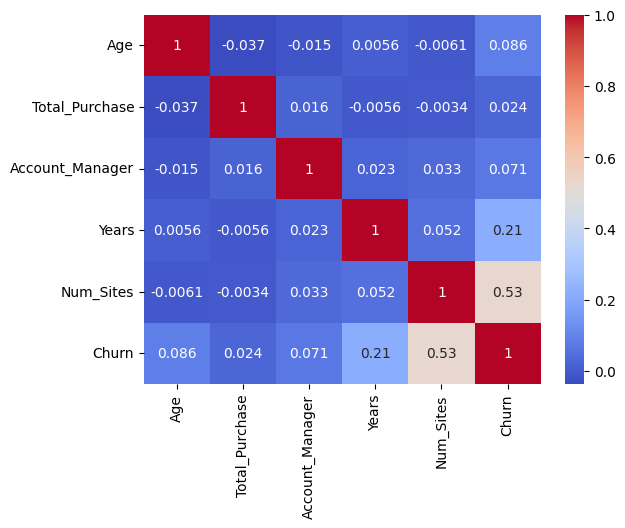

In [113]:
# Correlation between different aspects of the data to see which features are imp to predict the survival rate and which aren't

sns.heatmap(customer_churn.corr(numeric_only= True), annot= True, cmap= "coolwarm")

<Axes: xlabel='Churn', ylabel='count'>

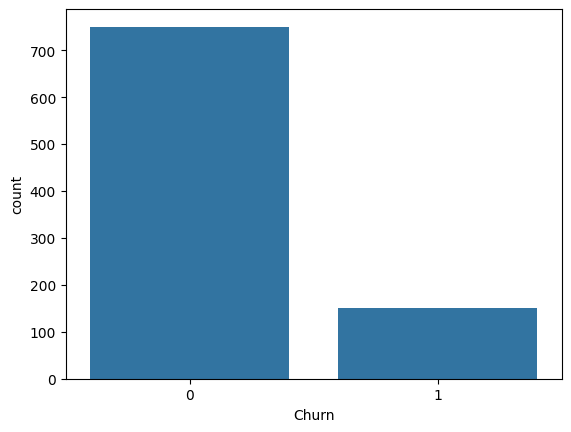

In [114]:
sns.countplot(x= 'Churn', data= customer_churn)

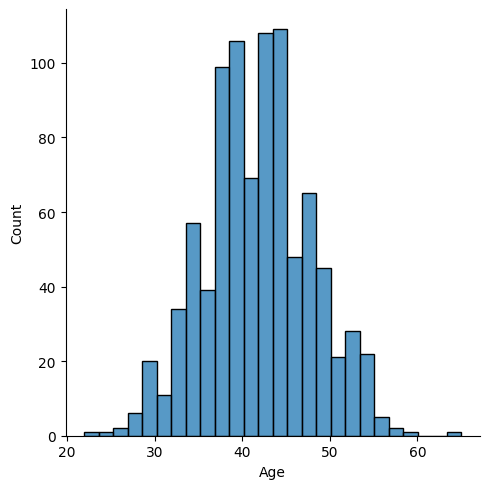

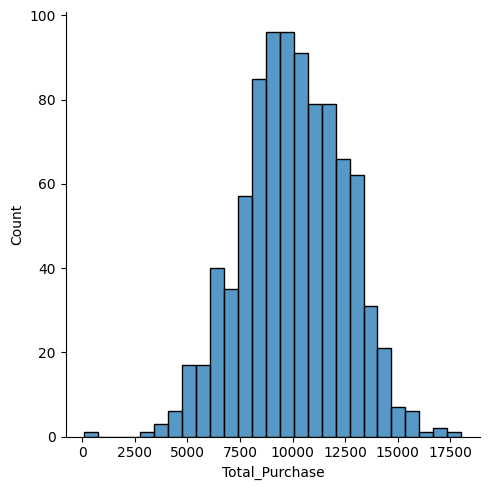

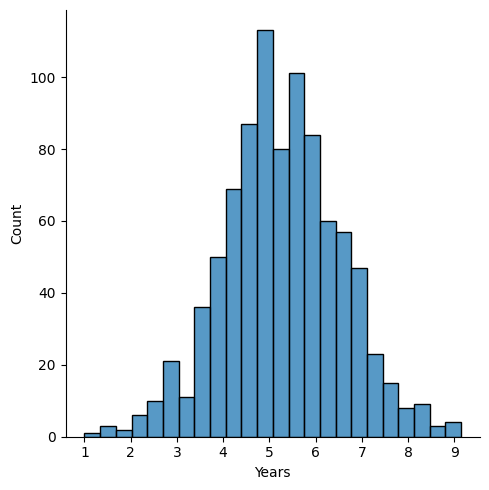

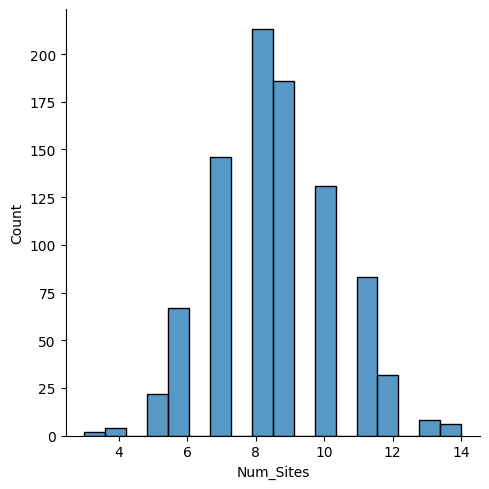

In [115]:
for col in ['Age', 'Total_Purchase', 'Years', 'Num_Sites']:
    sns.displot(customer_churn[col])


In [116]:
# separating features and target

X= customer_churn.drop("Churn", axis=1)
y= customer_churn['Churn']

# Train/ Test Split

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling Features

In [ ]:
scaler= StandardScaler()
X_train[:]= scaler.fit_transform(X_train)
X_test[:]= scaler.transform(X_test)

/var/folders/p_/8l92psx106q_nhcpkf5_sthw0000gn/T/ipykernel_23559/525589830.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.04547753  1.04547753 -0.95650071 -0.95650071  1.04547753 -0.95650071
  1.04547753  1.04547753  1.04547753  1.04547753  1.04547753 -0.95650071
 -0.95650071  1.04547753 -0.95650071 -0.95650071  1.04547753  1.04547753
 -0.95650071  1.04547753  1.04547753  1.04547753 -0.95650071 -0.95650071
  1.04547753  1.04547753  1.04547753  1.04547753 -0.95650071 -0.95650071
 -0.95650071  1.04547753 -0.95650071 -0.95650071 -0.95650071 -0.95650071
  1.04547753  1.04547753  1.04547753 -0.95650071  1.04547753  1.04547753
 -0.95650071  1.04547753 -0.95650071  1.04547753 -0.95650071 -0.95650071
 -0.95650071  1.04547753  1.04547753 -0.95650071  1.04547753 -0.95650071
 -0.95650071 -0.95650071 -0.95650071 -0.95650071 -0.95650071 -0.95650071
  1.04547753 -0.95650071  1.04547753 -0.95650071  1.04547753  1.0454775

In [119]:
# # principal component analysis (pca)
# from sklearn.decomposition import PCA
# pca= PCA(0.99) # 95% of imp data is extracted
# Xpca_train= pca.fit_transform(X_train)
# Xpca_test= pca.transform(X_test)


In [120]:
# X_train[:10]

In [121]:
# X_train= pd.DataFrame(X_train, columns= ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

In [122]:
X_train.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
10,-1.940415,0.609254,1.045478,-0.041546,-0.349420
334,-0.267443,-1.355415,1.045478,-0.774203,1.354300
244,-0.769335,2.039121,-0.956501,1.289842,-1.485234
678,0.234448,-1.709781,-0.956501,0.486282,-0.349420
306,0.736340,0.594198,1.045478,2.093401,0.786393


In [123]:
X_train.shape, X_test.shape

((720, 5), (180, 5))

# Cross validating the most appropriate model for the dataset

In [124]:
def kfold(estimator, inp, tar):
    return cross_val_score(estimator, inp, tar).mean()

In [125]:
kfold(LogisticRegression(), X_train, y_train)


np.float64(0.8902777777777777)

In [126]:
kfold(RandomForestClassifier(), X_train, y_train)


np.float64(0.8736111111111111)

In [127]:
kfold(SVC(), X_train, y_train)

np.float64(0.8833333333333332)

#### Logistic regression is the best model for this dataset

# Training the model

In [128]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [129]:
model.score(X_train, y_train) *100

83.05555555555556

# Evaluate the test data

In [130]:
prediction= model.predict(X_test)

In [131]:
model.score(X_test, y_test) * 100

83.88888888888889

In [132]:
pd.DataFrame(prediction, columns=['Predictions']).to_csv("Predictions_test.csv", index=False)

# Confusion Matrix

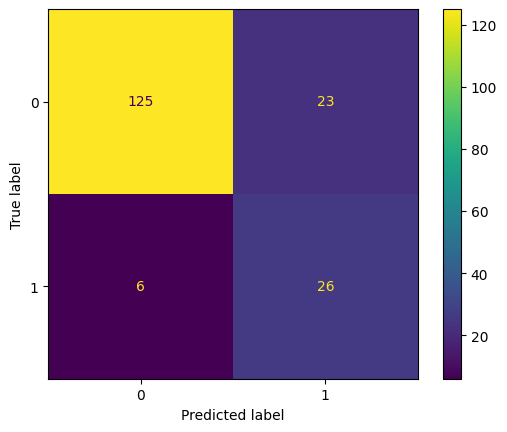

In [133]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [138]:
df= pd.read_csv("new_customers_1.csv")
df.drop(['Names', 'Location', 'Company', 'Onboard_date'], axis=1, inplace=True)


In [139]:
X_new = scaler.transform(df)


In [140]:
predictions_new = model.predict(X_new)
df['Churn_Prediction'] = predictions_new
print(df)

    Age  Total_Purchase  Account_Manager  Years  Num_Sites  Churn_Prediction
0  37.0         9935.53                1   7.71        8.0                 0
1  23.0         7526.94                1   9.28       15.0                 1
2  65.0          100.00                1   1.00       15.0                 1
3  32.0         6487.50                0   9.40       14.0                 1
4  32.0        13147.71                1  10.00        8.0                 1
5  22.0         8445.26                1   3.46       14.0                 1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [141]:
pd.DataFrame(predictions_new, columns=['Predictions']).to_csv("Predictions_new.csv", index=False)